# Sequence/Loss Analysis (Single + Multi Artifacts)


In [1]:
from __future__ import annotations

import json
from pathlib import Path
from collections import defaultdict
from statistics import mean

import pandas as pd
import matplotlib.pyplot as plt
import shutil
from analyze_problematic_segments import analyze_and_generate_circuits
import verify_circuits


In [2]:
# Edit directories here if needed
SINGLE_DIR = Path("artifacts/grover3-3")


In [3]:
def format_op(op: dict) -> str:
    op_name = op.get("operation", "?")
    qubits = op.get("qubits", [])
    params = op.get("params", [])
    q_str = ",".join(str(q) for q in qubits)
    if params:
        p_str = ", " + ", ".join(f"{float(p):.4f}" for p in params)
    else:
        p_str = ""
    return f"{op_name}({q_str}{p_str})"


def seq_key(ops: list[dict]) -> str:
    return " -> ".join(format_op(op) for op in ops)


def extract_sequences_from_ops(ops: list[dict], min_len: int = 2, max_len: int = 4) -> list[str]:
    out = []
    n = len(ops)
    for length in range(min_len, min(max_len + 1, n + 1)):
        for i in range(n - length + 1):
            out.append(seq_key(ops[i:i + length]))
    return out


def load_reports(artifact_dir: Path) -> list[dict]:
    files = sorted(artifact_dir.glob("delta_debug_report_*.json"))
    reports = []
    for fp in files:
        with fp.open("r", encoding="utf-8") as f:
            d = json.load(f)
        d["__file"] = str(fp)
        reports.append(d)
    return reports


def build_problematic_sequence_df(reports: list[dict], artifact_name: str) -> pd.DataFrame:
    rows = []
    for ridx, report in enumerate(reports):
        baseline_loss = float(report.get("baseline_loss", 0.0))
        problematic = set(report.get("problematic_segments", []))
        segs = (report.get("analysis") or {}).get("segments", [])
        by_layer = {s.get("layer_id"): s for s in segs}

        for seg_id in problematic:
            seg = by_layer.get(seg_id)
            if not seg:
                continue
            ops = seg.get("operations", [])
            for s in extract_sequences_from_ops(ops, min_len=2, max_len=4):
                rows.append({
                    "artifact": artifact_name,
                    "report_idx": ridx,
                    "report_file": report.get("__file"),
                    "segment_id": seg_id,
                    "sequence": s,
                    "baseline_loss": baseline_loss,
                })

    if not rows:
        return pd.DataFrame(columns=["artifact", "report_idx", "report_file", "segment_id", "sequence", "baseline_loss"])

    return pd.DataFrame(rows)


def aggregate_sequence_stats(seq_df: pd.DataFrame) -> pd.DataFrame:
    if seq_df.empty:
        return pd.DataFrame(columns=["sequence", "occurrences", "reports", "artifacts", "avg_baseline_loss", "max_baseline_loss"])

    grouped = seq_df.groupby("sequence", as_index=False).agg(
        occurrences=("sequence", "size"),
        reports=("report_file", lambda s: len(set(s))),
        artifacts=("artifact", lambda s: len(set(s))),
        avg_baseline_loss=("baseline_loss", "mean"),
        max_baseline_loss=("baseline_loss", "max"),
    )
    grouped = grouped.sort_values(["occurrences", "reports", "avg_baseline_loss"], ascending=False)
    return grouped


def _seq_index_name(i: int) -> str:
    return f"seq_{i:03d}.qpy"


def load_verified_sequence_loss_df(artifact_dir: Path) -> pd.DataFrame:
    seq_fp = artifact_dir / "sequence_analysis.json"
    cmp_fp = artifact_dir / "circuit_comparison_results.json"
    if not seq_fp.exists() or not cmp_fp.exists():
        return pd.DataFrame(columns=["artifact", "sequence", "file", "tvd_loss"])

    with seq_fp.open("r", encoding="utf-8") as f:
        seq_data = json.load(f)
    with cmp_fp.open("r", encoding="utf-8") as f:
        cmp_data = json.load(f)

    top_map = seq_data.get("top_10_sequences", {})
    ordered_sequences = list(top_map.keys())
    idx_to_seq = {_seq_index_name(i + 1): seq for i, seq in enumerate(ordered_sequences)}

    rows = []
    for item in cmp_data:
        file_name = item.get("file", "")
        seq = idx_to_seq.get(file_name)
        if seq is None:
            continue
        rows.append({
            "artifact": artifact_dir.name,
            "sequence": seq,
            "file": file_name,
            "tvd_loss": float(item.get("tvd_loss", 0.0)),
        })

    return pd.DataFrame(rows)


def plot_top_sequences_with_loss(agg_df: pd.DataFrame, title: str, top_n: int = 15):
    if agg_df.empty:
        print("No sequence data to plot.")
        return

    top = agg_df.head(top_n).copy()
    top = top.iloc[::-1]

    plt.figure(figsize=(12, max(6, top_n * 0.35)))
    bars = plt.barh(top["sequence"], top["occurrences"], color="steelblue")
    for bar, avg_loss in zip(bars, top["avg_baseline_loss"]):
        plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f"avg_loss={avg_loss:.4f}", va="center", fontsize=9)
    plt.xlabel("Occurrences in problematic segments")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_verified_tvd(verified_df: pd.DataFrame, title: str, top_n: int = 12):
    if verified_df.empty:
        print("No verification data (sequence_analysis.json + circuit_comparison_results.json) found.")
        return

    agg = verified_df.groupby("sequence", as_index=False).agg(
        runs=("tvd_loss", "size"),
        avg_tvd_loss=("tvd_loss", "mean"),
        max_tvd_loss=("tvd_loss", "max"),
        artifacts=("artifact", lambda s: len(set(s))),
    ).sort_values(["avg_tvd_loss", "runs"], ascending=False)

    top = agg.head(top_n).iloc[::-1]
    plt.figure(figsize=(12, max(6, top_n * 0.35)))
    bars = plt.barh(top["sequence"], top["avg_tvd_loss"], color="indianred")
    for bar, runs, arts in zip(bars, top["runs"], top["artifacts"]):
        plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, f"runs={runs}, artifacts={arts}", va="center", fontsize=9)
    plt.xlabel("Average TVD loss")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return agg

## 1) Grover3-3 Focus: Common Loss Sequences + 2025/2026 Overlap (Ratio-Based)

This section only analyzes `artifacts/grover3-3`:
- find recurring loss-related sequences from problematic segments
- compare 2025 vs 2026 using occurrence **ratios** (normalized within each year)
- inspect sequence overlap and ratio differences across years

Optional refresh: regenerate `sequence_analysis.json` before analysis (default on, no real-device call).


Refreshing sequence_analysis.json for artifacts/grover3-3 ...
Loading 6 report(s) from artifacts/grover3-3/ (searched 2 levels deep)...
  ✓ Loaded: artifacts/grover3-3/delta_debug_report_20251203_181408.json
  ✓ Loaded: artifacts/grover3-3/delta_debug_report_20251203_182255.json
  ✓ Loaded: artifacts/grover3-3/delta_debug_report_20251203_183508.json
  ✓ Loaded: artifacts/grover3-3/delta_debug_report_20251203_192251.json
  ✓ Loaded: artifacts/grover3-3/delta_debug_report_20260212_092716.json
  ✓ Loaded: artifacts/grover3-3/delta_debug_report_20260212_094319.json
✓ Loaded 6 reports

Sequence Analysis Summary

📊 Reports analyzed: 6
📊 Total unique sequences: 104

📋 Top 10 Sequences (sorted by frequency)
  sx(107) → rz(107, -2.7489)
    Count: 7, Reports: [1, 2, 5]
  rz(107, -2.7489) → sx(107)
    Count: 7, Reports: [1, 2, 5]
  sx(107) → rz(107, -2.7489) → sx(107)
    Count: 7, Reports: [1, 2, 5]
  sx(107) → rz(107, -3.1416)
    Count: 6, Reports: [0, 1, 2, 3, 4]
  rz(106, -1.9635) → sx(106

,Sequence,Total Occurrences (all rows),Number of Reports,Number of Artifacts,Avg Baseline Loss (occurrence-weighted),Max Baseline Loss
19,"rz(107, -2.7489) -> sx(107)",7,3,1,0.169782,0.201172
70,"sx(107) -> rz(107, -2.7489)",7,3,1,0.169782,0.201172
71,"sx(107) -> rz(107, -2.7489) -> sx(107)",7,3,1,0.169782,0.201172
76,"sx(107) -> rz(107, -3.1416)",6,5,1,0.160807,0.201172
27,"rz(107, 0.3927) -> sx(108)",4,4,1,0.173828,0.201172
28,"rz(107, 0.3927) -> sx(108) -> cz(108,107)",4,4,1,0.173828,0.201172
78,"sx(107) -> rz(107, 0.3927)",4,4,1,0.173828,0.201172
79,"sx(107) -> rz(107, 0.3927) -> sx(108)",4,4,1,0.173828,0.201172
80,"sx(107) -> rz(107, 0.3927) -> sx(108) -> cz(10...",4,4,1,0.173828,0.201172
90,"sx(108) -> cz(108,107)",4,4,1,0.173828,0.201172


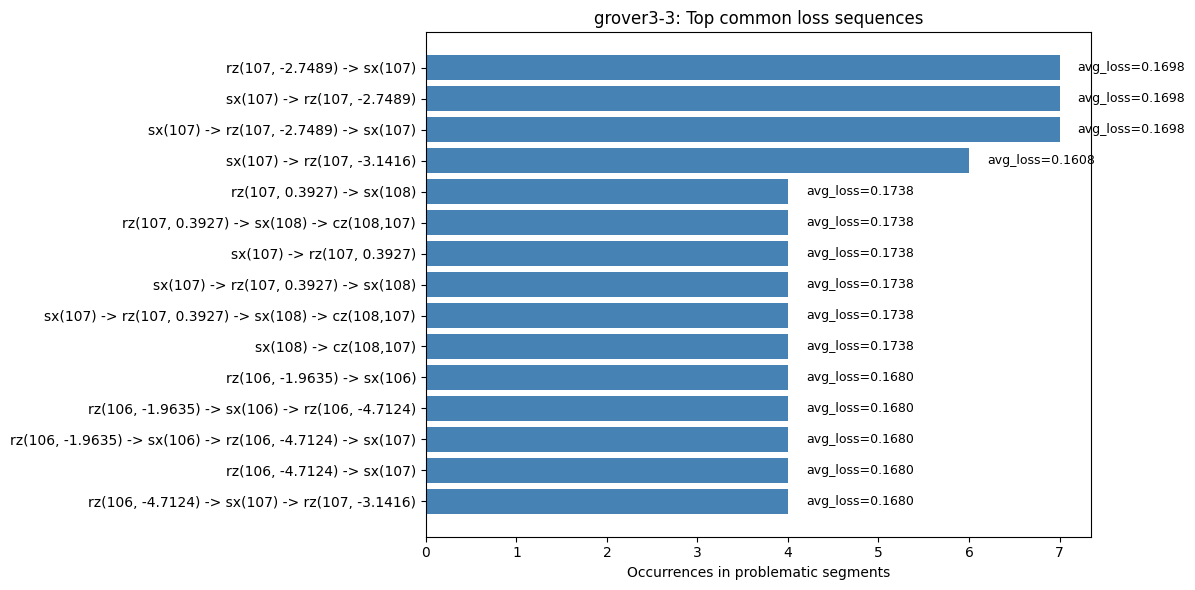


Year-level data volume
2025 reports: 4 | sequence rows: 264 | unique sequences: 104
2026 reports: 2 | sequence rows: 34 | unique sequences: 34

Top Sequences in 2025 (ratio-based)


,Sequence,Occurrence Count in 2025,Avg Baseline Loss in 2025,Reports Containing Sequence in 2025,Report Coverage Ratio in 2025
76,"sx(107) -> rz(107, -3.1416)",5,0.157617,4,1.00
52,"rz(97, 1.5708) -> sx(97) -> rz(97, 1.5708)",3,0.165039,3,0.75
50,"rz(97, 1.5708) -> rz(106, 1.5708) -> sx(106)",3,0.165039,3,0.75
78,"sx(107) -> rz(107, 0.3927)",3,0.165039,3,0.75
59,"sx(106) -> rz(106, -4.7124) -> sx(107) -> rz(1...",3,0.165039,3,0.75
58,"sx(106) -> rz(106, -4.7124) -> sx(107)",3,0.165039,3,0.75
57,"sx(106) -> rz(106, -4.7124)",3,0.165039,3,0.75
53,"rz(97, 1.5708) -> sx(97) -> rz(97, 1.5708) -> ...",3,0.165039,3,0.75
51,"rz(97, 1.5708) -> sx(97)",3,0.165039,3,0.75
49,"rz(97, 1.5708) -> rz(106, 1.5708)",3,0.165039,3,0.75



Top Sequences in 2026 (ratio-based)


,Sequence,Occurrence Count in 2026,Avg Baseline Loss in 2026,Reports Containing Sequence in 2026,Report Coverage Ratio in 2026
0,"rz(106, -1.9635) -> sx(106)",1,0.176758,1,0.5
25,"sx(107) -> rz(107, 2.7489)",1,0.176758,1,0.5
19,"sx(107) -> rz(107, -2.7489) -> sx(107)",1,0.200195,1,0.5
20,"sx(107) -> rz(107, -2.7489) -> sx(107) -> sx(108)",1,0.200195,1,0.5
21,"sx(107) -> rz(107, -3.1416)",1,0.176758,1,0.5
22,"sx(107) -> rz(107, 0.3927)",1,0.200195,1,0.5
23,"sx(107) -> rz(107, 0.3927) -> sx(108)",1,0.200195,1,0.5
24,"sx(107) -> rz(107, 0.3927) -> sx(108) -> cz(10...",1,0.200195,1,0.5
26,"sx(107) -> rz(107, 2.7489) -> sx(107)",1,0.176758,1,0.5
1,"rz(106, -1.9635) -> sx(106) -> rz(106, -4.7124)",1,0.176758,1,0.5



Overlap summary
Intersection sequence count: 34

Intersection details


,Sequence,Occurrence Count in 2025,Reports Containing Sequence in 2025,Report Coverage Ratio in 2025,Avg Baseline Loss in 2025,Occurrence Count in 2026,Reports Containing Sequence in 2026,Report Coverage Ratio in 2026,Avg Baseline Loss in 2026,Report Coverage Ratio Difference (2026 - 2025)
17,"sx(107) -> cz(97,107)",3,2,0.50,0.164714,1,1,0.5,0.200195,0.00
6,"rz(107, -2.7489) -> sx(107) -> sx(108)",2,2,0.50,0.146484,1,1,0.5,0.200195,0.00
20,"sx(107) -> rz(107, -2.7489) -> sx(107) -> sx(108)",2,2,0.50,0.146484,1,1,0.5,0.200195,0.00
27,sx(107) -> sx(108),2,2,0.50,0.146484,1,1,0.5,0.200195,0.00
18,"sx(107) -> rz(107, -2.7489)",6,2,0.50,0.164714,1,1,0.5,0.200195,0.00
7,"rz(107, -2.7489) -> sx(107) -> sx(108) -> rz(1...",2,2,0.50,0.146484,1,1,0.5,0.200195,0.00
28,"sx(107) -> sx(108) -> rz(108, 0.7626)",2,2,0.50,0.146484,1,1,0.5,0.200195,0.00
5,"rz(107, -2.7489) -> sx(107)",6,2,0.50,0.164714,1,1,0.5,0.200195,0.00
30,"sx(108) -> rz(108, 0.7626)",2,2,0.50,0.146484,1,1,0.5,0.200195,0.00
19,"sx(107) -> rz(107, -2.7489) -> sx(107)",6,2,0.50,0.164714,1,1,0.5,0.200195,0.00


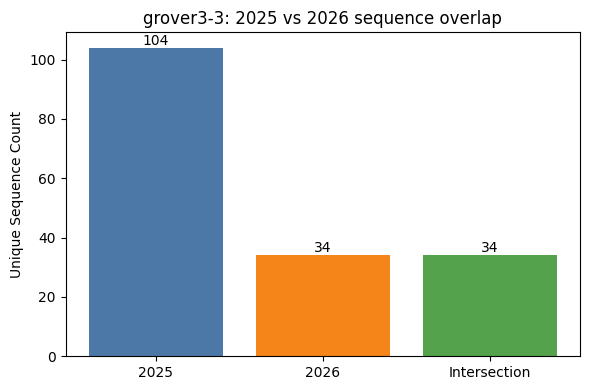

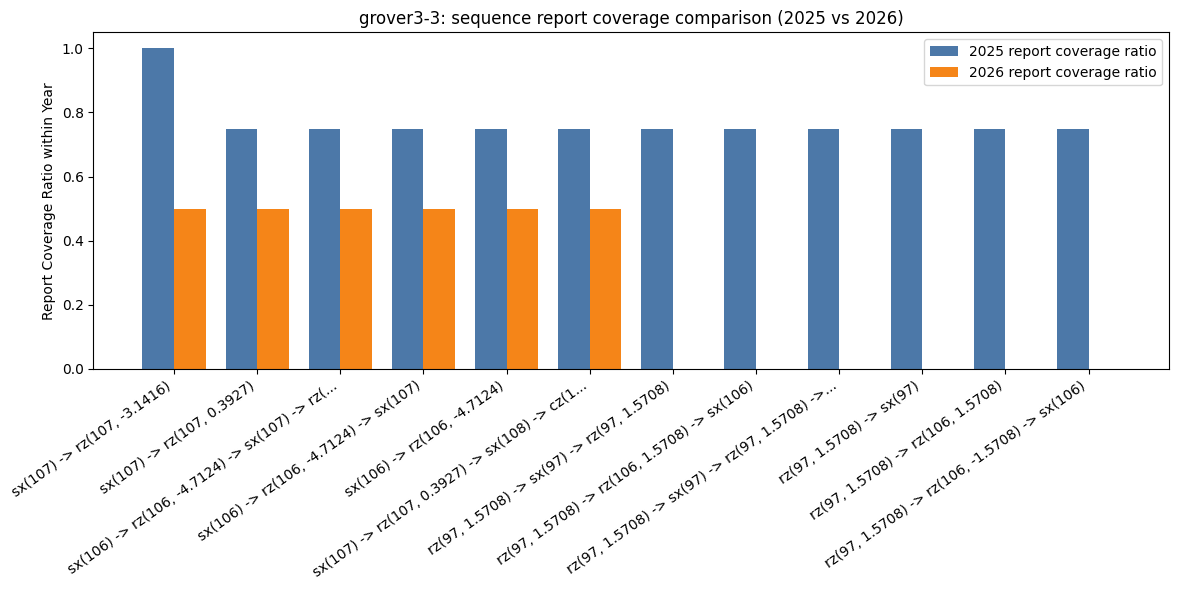


Top ratio comparison table


,Sequence,Report Coverage Ratio in 2025,Occurrence Count in 2025,Reports Containing Sequence in 2025,Report Coverage Ratio in 2026,Occurrence Count in 2026,Reports Containing Sequence in 2026
0,"sx(107) -> rz(107, -3.1416)",1.00,5,4,0.5,1.0,1.0
3,"sx(107) -> rz(107, 0.3927)",0.75,3,3,0.5,1.0,1.0
4,"sx(106) -> rz(106, -4.7124) -> sx(107) -> rz(1...",0.75,3,3,0.5,1.0,1.0
5,"sx(106) -> rz(106, -4.7124) -> sx(107)",0.75,3,3,0.5,1.0,1.0
6,"sx(106) -> rz(106, -4.7124)",0.75,3,3,0.5,1.0,1.0
10,"sx(107) -> rz(107, 0.3927) -> sx(108) -> cz(10...",0.75,3,3,0.5,1.0,1.0
1,"rz(97, 1.5708) -> sx(97) -> rz(97, 1.5708)",0.75,3,3,0.0,0.0,0.0
2,"rz(97, 1.5708) -> rz(106, 1.5708) -> sx(106)",0.75,3,3,0.0,0.0,0.0
7,"rz(97, 1.5708) -> sx(97) -> rz(97, 1.5708) -> ...",0.75,3,3,0.0,0.0,0.0
8,"rz(97, 1.5708) -> sx(97)",0.75,3,3,0.0,0.0,0.0


In [4]:

import re

REFRESH_SEQUENCE_BEFORE_SECTION1 = True

if REFRESH_SEQUENCE_BEFORE_SECTION1:
    print(f"Refreshing sequence_analysis.json for {SINGLE_DIR} ...")
    analysis = analyze_and_generate_circuits(str(SINGLE_DIR), "tmp")
    if analysis is not None:
        shutil.copy2("tmp/sequence_analysis.json", SINGLE_DIR / "sequence_analysis.json")
        (SINGLE_DIR / "circuits").mkdir(parents=True, exist_ok=True)
        for f in Path("tmp/circuits").glob("*"):
            if f.is_file():
                shutil.copy2(f, SINGLE_DIR / "circuits" / f.name)
        print("sequence_analysis.json refreshed")
    else:
        print("Sequence refresh failed; continue with existing files.")

single_reports = load_reports(SINGLE_DIR)
print(f"{SINGLE_DIR}: loaded reports = {len(single_reports)}")

single_seq_df = build_problematic_sequence_df(single_reports, SINGLE_DIR.name)
single_seq_df["year"] = single_seq_df["report_file"].apply(
    lambda s: int(re.search(r"delta_debug_report_(\d{4})", str(s)).group(1)) if re.search(r"delta_debug_report_(\d{4})", str(s)) else None
)

single_agg = aggregate_sequence_stats(single_seq_df)
single_agg_view = single_agg.rename(columns={
    "sequence": "Sequence",
    "occurrences": "Total Occurrences (all rows)",
    "reports": "Number of Reports",
    "artifacts": "Number of Artifacts",
    "avg_baseline_loss": "Avg Baseline Loss (occurrence-weighted)",
    "max_baseline_loss": "Max Baseline Loss",
})

print("\nOverall Top Sequences")
display(single_agg_view.head(20))
plot_top_sequences_with_loss(single_agg, title=f"{SINGLE_DIR.name}: Top common loss sequences")

# ---- 2025 vs 2026 using report coverage ratio: reports containing sequence / total reports in that year ----
y2025 = single_seq_df[single_seq_df["year"] == 2025].copy()
y2026 = single_seq_df[single_seq_df["year"] == 2026].copy()

print("\nYear-level data volume")
print("2025 reports:", y2025["report_file"].nunique(), "| sequence rows:", len(y2025), "| unique sequences:", y2025["sequence"].nunique())
print("2026 reports:", y2026["report_file"].nunique(), "| sequence rows:", len(y2026), "| unique sequences:", y2026["sequence"].nunique())

agg_2025 = y2025.groupby("sequence", as_index=False).agg(count_2025=("sequence", "size"), avg_loss_2025=("baseline_loss", "mean"))
agg_2026 = y2026.groupby("sequence", as_index=False).agg(count_2026=("sequence", "size"), avg_loss_2026=("baseline_loss", "mean"))

# report coverage ratio: reports containing this sequence / total reports in that year
report_cov_2025 = y2025.groupby("sequence")["report_file"].nunique().reset_index(name="reports_with_sequence_2025")
report_cov_2026 = y2026.groupby("sequence")["report_file"].nunique().reset_index(name="reports_with_sequence_2026")

total_reports_2025 = max(y2025["report_file"].nunique(), 1)
total_reports_2026 = max(y2026["report_file"].nunique(), 1)

agg_2025 = agg_2025.merge(report_cov_2025, on="sequence", how="left")
agg_2026 = agg_2026.merge(report_cov_2026, on="sequence", how="left")

agg_2025["report_ratio_2025"] = agg_2025["reports_with_sequence_2025"] / total_reports_2025
agg_2026["report_ratio_2026"] = agg_2026["reports_with_sequence_2026"] / total_reports_2026

agg_2025_view = agg_2025.sort_values("report_ratio_2025", ascending=False).rename(columns={
    "sequence": "Sequence",
    "count_2025": "Occurrence Count in 2025",
    "reports_with_sequence_2025": "Reports Containing Sequence in 2025",
    "report_ratio_2025": "Report Coverage Ratio in 2025",
    "avg_loss_2025": "Avg Baseline Loss in 2025",
})
agg_2026_view = agg_2026.sort_values("report_ratio_2026", ascending=False).rename(columns={
    "sequence": "Sequence",
    "count_2026": "Occurrence Count in 2026",
    "reports_with_sequence_2026": "Reports Containing Sequence in 2026",
    "report_ratio_2026": "Report Coverage Ratio in 2026",
    "avg_loss_2026": "Avg Baseline Loss in 2026",
})

print("\nTop Sequences in 2025 (ratio-based)")
display(agg_2025_view.head(15))
print("\nTop Sequences in 2026 (ratio-based)")
display(agg_2026_view.head(15))

set_2025 = set(agg_2025["sequence"])
set_2026 = set(agg_2026["sequence"])
intersection = set_2025 & set_2026

print("\nOverlap summary")
print("Intersection sequence count:", len(intersection))

intersection_df = pd.DataFrame({"sequence": sorted(intersection)})
if not intersection_df.empty:
    intersection_df = (intersection_df
        .merge(agg_2025[["sequence", "count_2025", "reports_with_sequence_2025", "report_ratio_2025", "avg_loss_2025"]], on="sequence", how="left")
        .merge(agg_2026[["sequence", "count_2026", "reports_with_sequence_2026", "report_ratio_2026", "avg_loss_2026"]], on="sequence", how="left")
    )
    intersection_df["report_ratio_diff_2026_minus_2025"] = intersection_df["report_ratio_2026"] - intersection_df["report_ratio_2025"]
    intersection_df = intersection_df.sort_values("report_ratio_diff_2026_minus_2025", ascending=False)

intersection_view = intersection_df.rename(columns={
    "sequence": "Sequence",
    "count_2025": "Occurrence Count in 2025",
    "reports_with_sequence_2025": "Reports Containing Sequence in 2025",
    "report_ratio_2025": "Report Coverage Ratio in 2025",
    "avg_loss_2025": "Avg Baseline Loss in 2025",
    "count_2026": "Occurrence Count in 2026",
    "reports_with_sequence_2026": "Reports Containing Sequence in 2026",
    "report_ratio_2026": "Report Coverage Ratio in 2026",
    "avg_loss_2026": "Avg Baseline Loss in 2026",
    "report_ratio_diff_2026_minus_2025": "Report Coverage Ratio Difference (2026 - 2025)",
})

print("\nIntersection details")
display(intersection_view.head(30))

# Set-size visualization
plt.figure(figsize=(6,4))
bars = plt.bar(["2025", "2026", "Intersection"], [len(set_2025), len(set_2026), len(intersection)], color=["#4C78A8", "#F58518", "#54A24B"])
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f"{int(b.get_height())}", ha="center", va="bottom")
plt.ylabel("Unique Sequence Count")
plt.title(f"{SINGLE_DIR.name}: 2025 vs 2026 sequence overlap")
plt.tight_layout()
plt.show()

# Ratio comparison visualization (not raw counts)
TOPN = 12
plot_seq = list(dict.fromkeys(
    list(agg_2025.sort_values("report_ratio_2025", ascending=False).head(TOPN)["sequence"]) +
    list(agg_2026.sort_values("report_ratio_2026", ascending=False).head(TOPN)["sequence"])
))[:TOPN]

cmp = pd.DataFrame({"sequence": plot_seq})
cmp = cmp.merge(agg_2025[["sequence", "report_ratio_2025", "count_2025", "reports_with_sequence_2025"]], on="sequence", how="left")
cmp = cmp.merge(agg_2026[["sequence", "report_ratio_2026", "count_2026", "reports_with_sequence_2026"]], on="sequence", how="left")
cmp = cmp.fillna(0)
cmp = cmp.sort_values(["report_ratio_2025", "report_ratio_2026"], ascending=False)

if not cmp.empty:
    x = range(len(cmp))
    w = 0.38
    plt.figure(figsize=(12,6))
    plt.bar([i - w/2 for i in x], cmp["report_ratio_2025"], width=w, label="2025 report coverage ratio", color="#4C78A8")
    plt.bar([i + w/2 for i in x], cmp["report_ratio_2026"], width=w, label="2026 report coverage ratio", color="#F58518")
    plt.xticks(list(x), [s[:45] + ("..." if len(s) > 45 else "") for s in cmp["sequence"]], rotation=35, ha="right")
    plt.ylabel("Report Coverage Ratio within Year")
    plt.title(f"{SINGLE_DIR.name}: sequence report coverage comparison (2025 vs 2026)")
    plt.legend()
    plt.tight_layout()
    plt.show()

cmp_view = cmp.rename(columns={
    "sequence": "Sequence",
    "count_2025": "Occurrence Count in 2025",
    "reports_with_sequence_2025": "Reports Containing Sequence in 2025",
    "report_ratio_2025": "Report Coverage Ratio in 2025",
    "count_2026": "Occurrence Count in 2026",
    "reports_with_sequence_2026": "Reports Containing Sequence in 2026",
    "report_ratio_2026": "Report Coverage Ratio in 2026",
})

print("\nTop ratio comparison table")
display(cmp_view)
